# Understanding the Kerr Oscillator Hamiltonian

This notebook explores the spectrum of a single bosonic mode with a Kerr nonlinearity, the workhorse Hamiltonian for driven-dissipative cat qubits and Kerr-cat encodings. We sweep the Kerr coefficient $K$ and track how the harmonic ladder bends into an anharmonic one.


## Imports


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from gkp_optimal_control.plotting import set_plot_style

set_plot_style()

## System operators

The Kerr Hamiltonian is
$$
H(K) = \hat{a}^\dagger \hat{a} + K \, (\hat{a}^\dagger \hat{a})^2,
$$
so the Fock states $\ket{n}$ are exact eigenstates with energies $E_n = n + K n^2$. We truncate the Hilbert space to $n_{\text{fock}}$ levels and build the resonator term $H_{\text{res}} = \hat{a}^\dagger \hat{a}$ and the Kerr term $H_{\text{kerr}} = (\hat{a}^\dagger \hat{a})^2$ separately so we can sweep their relative weight.


In [2]:
n_fock = 60

a = qt.destroy(n_fock)
num_op = a.dag() * a

h_res = num_op
h_kerr = num_op**2

## Sweeping the Kerr coefficient

For each value of $K$ we diagonalize $H(K) = H_{\text{res}} + K\, H_{\text{kerr}}$ and keep the lowest ``n_levels`` eigenvalues. QuTiP's ``eigenenergies(eigvals=n_levels)`` returns them already sorted in ascending order, which avoids diagonalizing the full truncated space.


In [3]:
def kerr_spectrum(kerr_values: np.ndarray, n_levels: int) -> np.ndarray:
    """Return an array of shape (len(kerr_values), n_levels) of the lowest eigenvalues."""
    energies = np.empty((len(kerr_values), n_levels))
    for i, k in enumerate(kerr_values):
        energies[i] = np.real(
            (h_res + k * h_kerr).eigenenergies(eigvals=n_levels)
        )
    return energies

## Energy levels vs Kerr

At $K = 0$ the levels are equally spaced at $E_n = n$. Turning on $K$ adds a quadratic term $K n^2$, so higher levels climb faster and the ladder fans out.


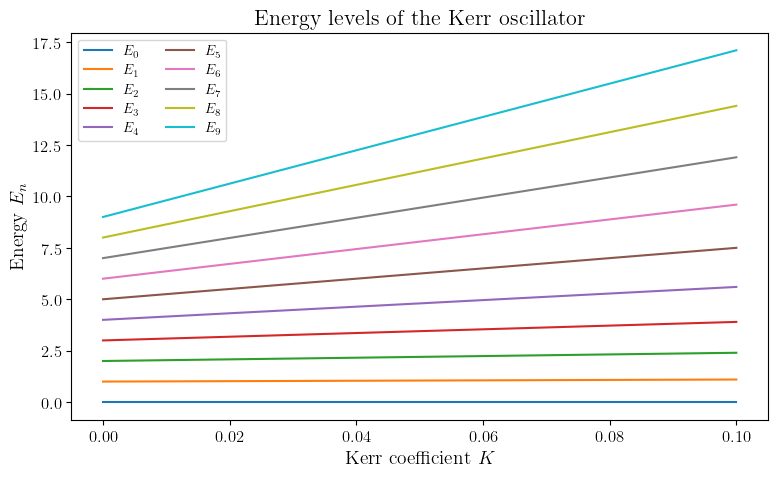

In [4]:
n_levels = 10
kerr_values = np.linspace(0, 0.1, 100)
energies = kerr_spectrum(kerr_values, n_levels)

fig, ax = plt.subplots(figsize=(8, 5))
for n in range(n_levels):
    ax.plot(kerr_values, energies[:, n], label=rf"$E_{{{n}}}$")

ax.set_xlabel(r"Kerr coefficient $K$")
ax.set_ylabel(r"Energy $E_n$")
ax.set_title("Energy levels of the Kerr oscillator")
ax.legend(ncol=2, fontsize=10)

fig.tight_layout()
fig.savefig("../../figs/foundations/kerr_energy_levels.pdf", bbox_inches="tight")
plt.show()

## Level spacings vs Kerr

The consecutive spacing $\Delta E_{n, n+1} = E_{n+1} - E_n = 1 + K(2n + 1)$ is linear in $K$ with slope $2n + 1$, so higher transitions separate from lower ones as $K$ grows. This anharmonicity is what makes adjacent energy levels selectively addressable. A drive resonant with the $\ket{0} \leftrightarrow \ket{1}$ transition does not excite $\ket{1} \leftrightarrow \ket{2}$.


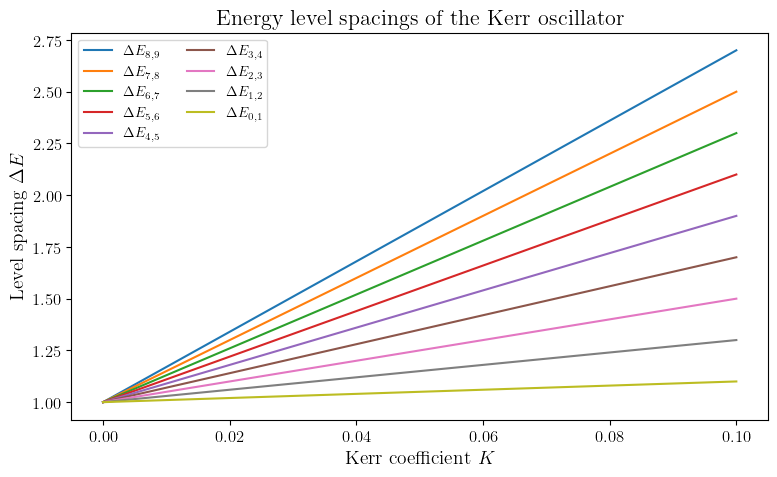

In [5]:
level_spacings = np.diff(energies, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
for n in reversed(range(level_spacings.shape[1])):
    ax.plot(
        kerr_values,
        level_spacings[:, n],
        label=rf"$\Delta E_{{{n}, {n + 1}}}$",
    )

ax.set_xlabel(r"Kerr coefficient $K$")
ax.set_ylabel(r"Level spacing $\Delta E$")
ax.set_title("Energy level spacings of the Kerr oscillator")
ax.legend(ncol=2, fontsize=10)

fig.tight_layout()
fig.savefig("../../figs/foundations/kerr_level_spacings.pdf", bbox_inches="tight")
plt.show()